In [91]:
import pandas as pd
import numpy as np

In [92]:
dataset = pd.read_csv(r'/home/ducvu0904/Downloads/xstk/injury+stat.csv')

In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

df = pd.read_csv("/home/ducvu0904/Downloads/xstk/injury+stat.csv")

# Standardize a few key fields for repeated use across sections
for c in ["DAYS_MISSED", "USG_PCT", "AGE", "PACE", "AVG_SPEED", "GP", "MIN", "POSS", "DRIVES", "FGA_PG"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

for c in ["INJURED_ON", "RETURNED"]:
    if c in df.columns:
        # dayfirst=True handles common sport data formats (dd/mm/yyyy)
        df[c] = pd.to_datetime(df[c], errors="coerce", dayfirst=True)

injury_date_col = "INJURED_ON"
days_col = "DAYS_MISSED"

# Injury flag: either valid injury date or days missed > 0
df["injury_flag"] = False
if injury_date_col in df.columns:
    df.loc[df[injury_date_col].notna(), "injury_flag"] = True
if days_col in df.columns:
    df.loc[df[days_col].fillna(0) > 0, "injury_flag"] = True

print(f"Rows: {len(df):,}")
print(f"Players: {df['PLAYER_ID'].nunique():,}")
print(f"Teams: {df['TEAM'].nunique():,}")
print(f"Injury rows: {int(df['injury_flag'].sum()):,}")

display(df.head(3))

Rows: 5,572
Players: 1,387
Teams: 30
Injury rows: 1,214


,PLAYER_ID,PLAYER_NAME,SEASON,SEASON_NUM,AGE,PLAYER_HEIGHT_INCHES,PLAYER_WEIGHT,GP,MIN,USG_PCT,PACE,POSS,FGA_PG,DRIVES,DRIVE_FGA,DRIVE_PASSES,DIST_MILES,AVG_SPEED,PULL_UP_FGA,PULL_UP_FG3A,TOUCHES,FRONT_CT_TOUCHES,AVG_SEC_PER_TOUCH,AVG_DRIB_PER_TOUCH,ELBOW_TOUCHES,POST_TOUCHES,PAINT_TOUCHES,TEAM,INJURED_ON,RETURNED,DAYS_MISSED,INJURED_TYPE,injury_flag
0,1630639,A.J. Lawson,22-23,22.5,22.0,78.0,179.0,13,4.8,0.182,106.08,139,2.0,0.1,0.0,0.1,0.39,4.49,0.2,0.1,4.8,3.2,1.39,0.62,0.0,0.0,0.2,NaN,NaT,NaT,NaN,NaN,False
1,1631260,AJ Green,22-23,22.5,23.0,77.0,190.0,32,9.4,0.160,102.85,651,3.4,0.3,0.0,0.3,0.74,4.36,1.1,0.7,11.9,7.3,2.61,1.84,0.1,0.0,0.3,NaN,NaT,NaT,NaN,NaN,False
2,1631100,AJ Griffin,22-23,22.5,19.0,78.0,220.0,66,19.4,0.174,102.71,2749,7.4,2.8,1.8,0.7,1.58,4.56,2.5,0.8,21.1,14.2,2.08,1.49,0.4,0.0,0.7,NaN,NaT,NaT,NaN,NaN,False


In [94]:
feature = pd.DataFrame(df.columns.tolist())
feature

,0
0,PLAYER_ID
1,PLAYER_NAME
2,SEASON
3,SEASON_NUM
4,AGE
5,PLAYER_HEIGHT_INCHES
6,PLAYER_WEIGHT
7,GP
8,MIN
9,USG_PCT


## 1) Tần suất vs mức độ nghiêm trọng
- Tần suất: số lần xuất hiện theo loại chấn thương.
- Nghiêm trọng: trung bình số ngày nghỉ (`DAYS MISSED`).

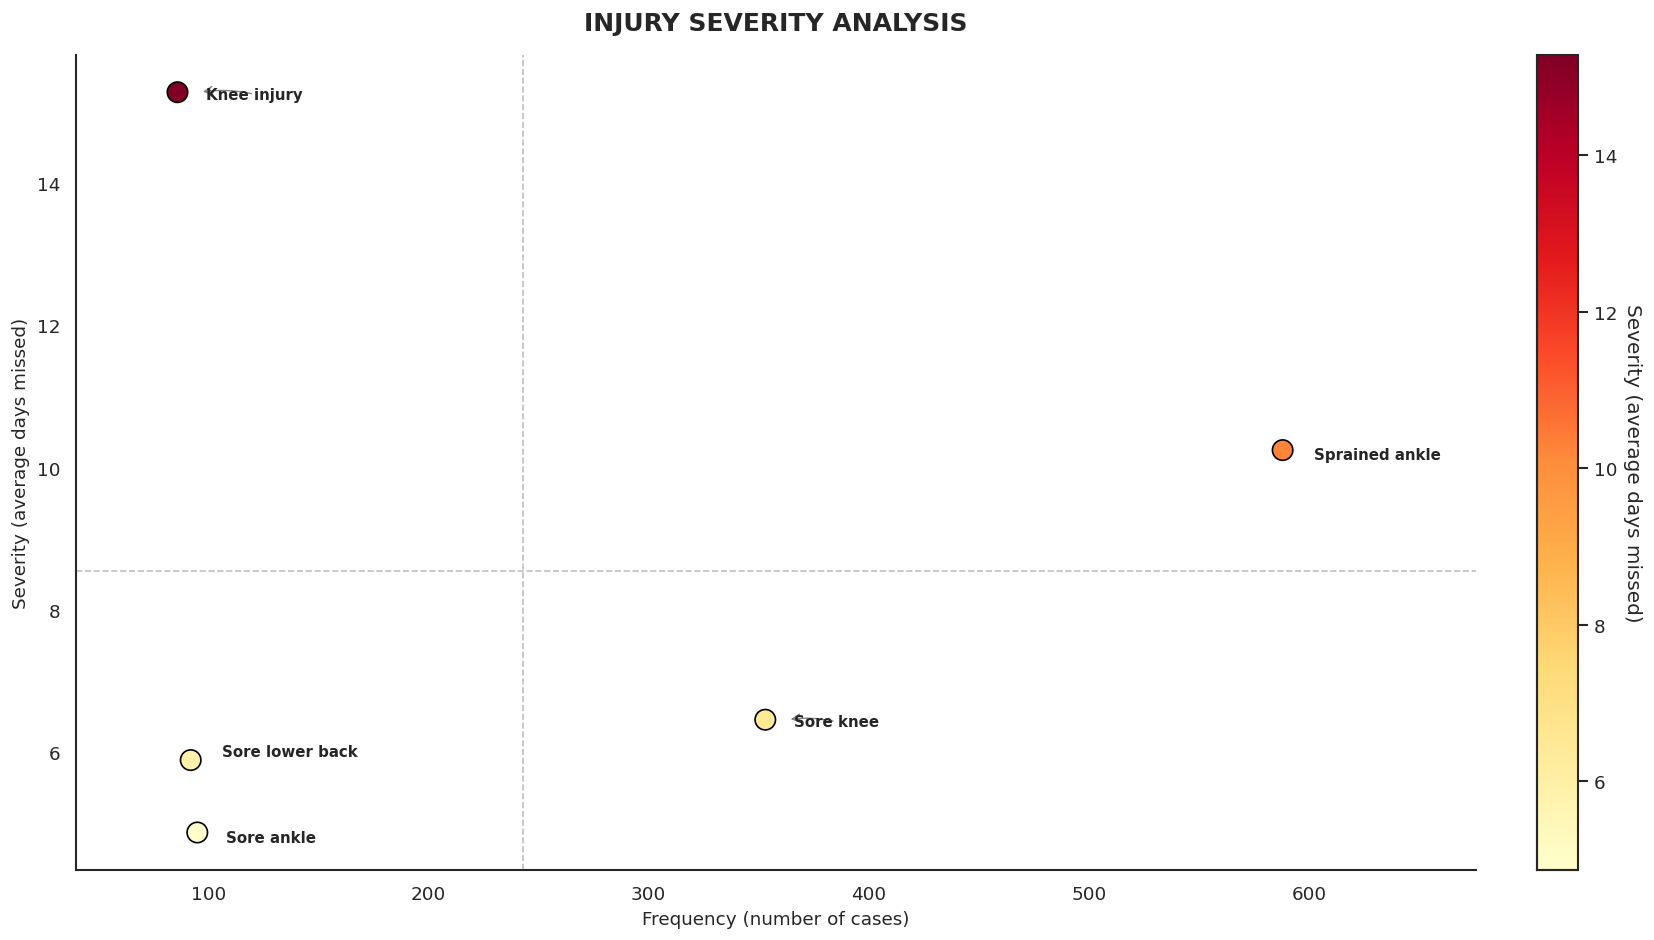

In [95]:
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text

sns.set_theme(style="white", font="sans-serif")
plt.rcParams['figure.dpi'] = 120

def visualize_injury_analysis(df, inj_type="INJURED_TYPE", days_col="DAYS_MISSED"):
    if inj_type not in df.columns or days_col not in df.columns:
        print(f"Lỗi: Thiếu cột {inj_type} hoặc {days_col}")
        return

    tmp = df[(df["injury_flag"] == True) & df[inj_type].notna() & df[days_col].notna()].copy()
    if tmp.empty:
        print("Không có dữ liệu chấn thương hợp lệ để vẽ.")
        return

    plot_df = (
        tmp.groupby(inj_type)
        .agg(
            injury_count=("injury_flag", "size"),
            avg_days_missed=(days_col, "mean")
        )
        .sort_values("injury_count", ascending=False)
        .head(15)
        .reset_index()
    )

    if plot_df.empty:
        print("Không có nhóm chấn thương nào sau khi tổng hợp dữ liệu.")
        return

    fig, ax = plt.subplots(figsize=(14, 8))
    
    m_x = plot_df["injury_count"].mean()
    m_y = plot_df["avg_days_missed"].mean()

    xlim = (plot_df["injury_count"].min() * 0.8, plot_df["injury_count"].max() * 1.1)
    ylim = (plot_df["avg_days_missed"].min() * 0.8, plot_df["avg_days_missed"].max() * 1.1)
    
    ax.axvspan(m_x, xlim[1], m_y, ylim[1], color="#fce4ec", alpha=0.3)
    ax.axvspan(xlim[0], m_x, m_y, ylim[1], color="#fff3e0", alpha=0.3)
    ax.axvspan(m_x, xlim[1], ylim[0], m_y, color="#e3f2fd", alpha=0.3)
    ax.axvspan(xlim[0], m_x, ylim[0], m_y, color="#e8f5e9", alpha=0.3)

    sns.scatterplot(
        data=plot_df,
        x="injury_count",
        y="avg_days_missed",
        hue="avg_days_missed",
        palette="YlOrRd",
        s=150,
        edgecolor="black",
        linewidth=1,
        zorder=5,
        ax=ax
    )

    ax.axvline(m_x, color="grey", linestyle="--", linewidth=1, alpha=0.5, zorder=2)
    ax.axhline(m_y, color="grey", linestyle="--", linewidth=1, alpha=0.5, zorder=2)

    x_offset = (plot_df["injury_count"].max() - plot_df["injury_count"].min()) * 0.02

    texts = []
    for _, r in plot_df.iterrows():
        # Convert snake_case label to readable lowercase text
        pretty_label = str(r[inj_type]).replace("_", " ").strip()
        texts.append(ax.text(
            r["injury_count"] + x_offset,
            r["avg_days_missed"],
            pretty_label,
            fontsize=9,
            fontweight="bold",
            va="center",
            zorder=10
        ))

    adjust_text(
        texts,
        x=plot_df["injury_count"].values,
        y=plot_df["avg_days_missed"].values,
        expand_points=(1.5, 1.0),
        expand_text=(1.2, 1.0),
        force_points=(0.5, 0.1),
        force_text=(0.3, 0.1),
        only_move={"points": "x", "text": "x"},
        arrowprops=dict(
            arrowstyle="->",
            color="gray",
            lw=0.8,
            connectionstyle="arc3,rad=0.1"
        ),
        ax=ax
    )

    ax.set_title("INJURY SEVERITY ANALYSIS", fontsize=15, weight="bold", pad=15)
    ax.set_xlabel("Frequency (number of cases)", fontsize=11)
    ax.set_ylabel("Severity (average days missed)", fontsize=11)
    
    norm = plt.Normalize(plot_df["avg_days_missed"].min(), plot_df["avg_days_missed"].max())
    sm = plt.cm.ScalarMappable(cmap="YlOrRd", norm=norm)
    sm.set_array([])
    
    legend = ax.get_legend()
    if legend is not None:
        legend.remove()
    cbar = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Severity (average days missed)", rotation=270, labelpad=15)

    sns.despine()
    plt.tight_layout()
    plt.show()

visualize_injury_analysis(df)

Đã lưu biểu đồ vào file 'injury_trends_two_subplots_one_figure.png'


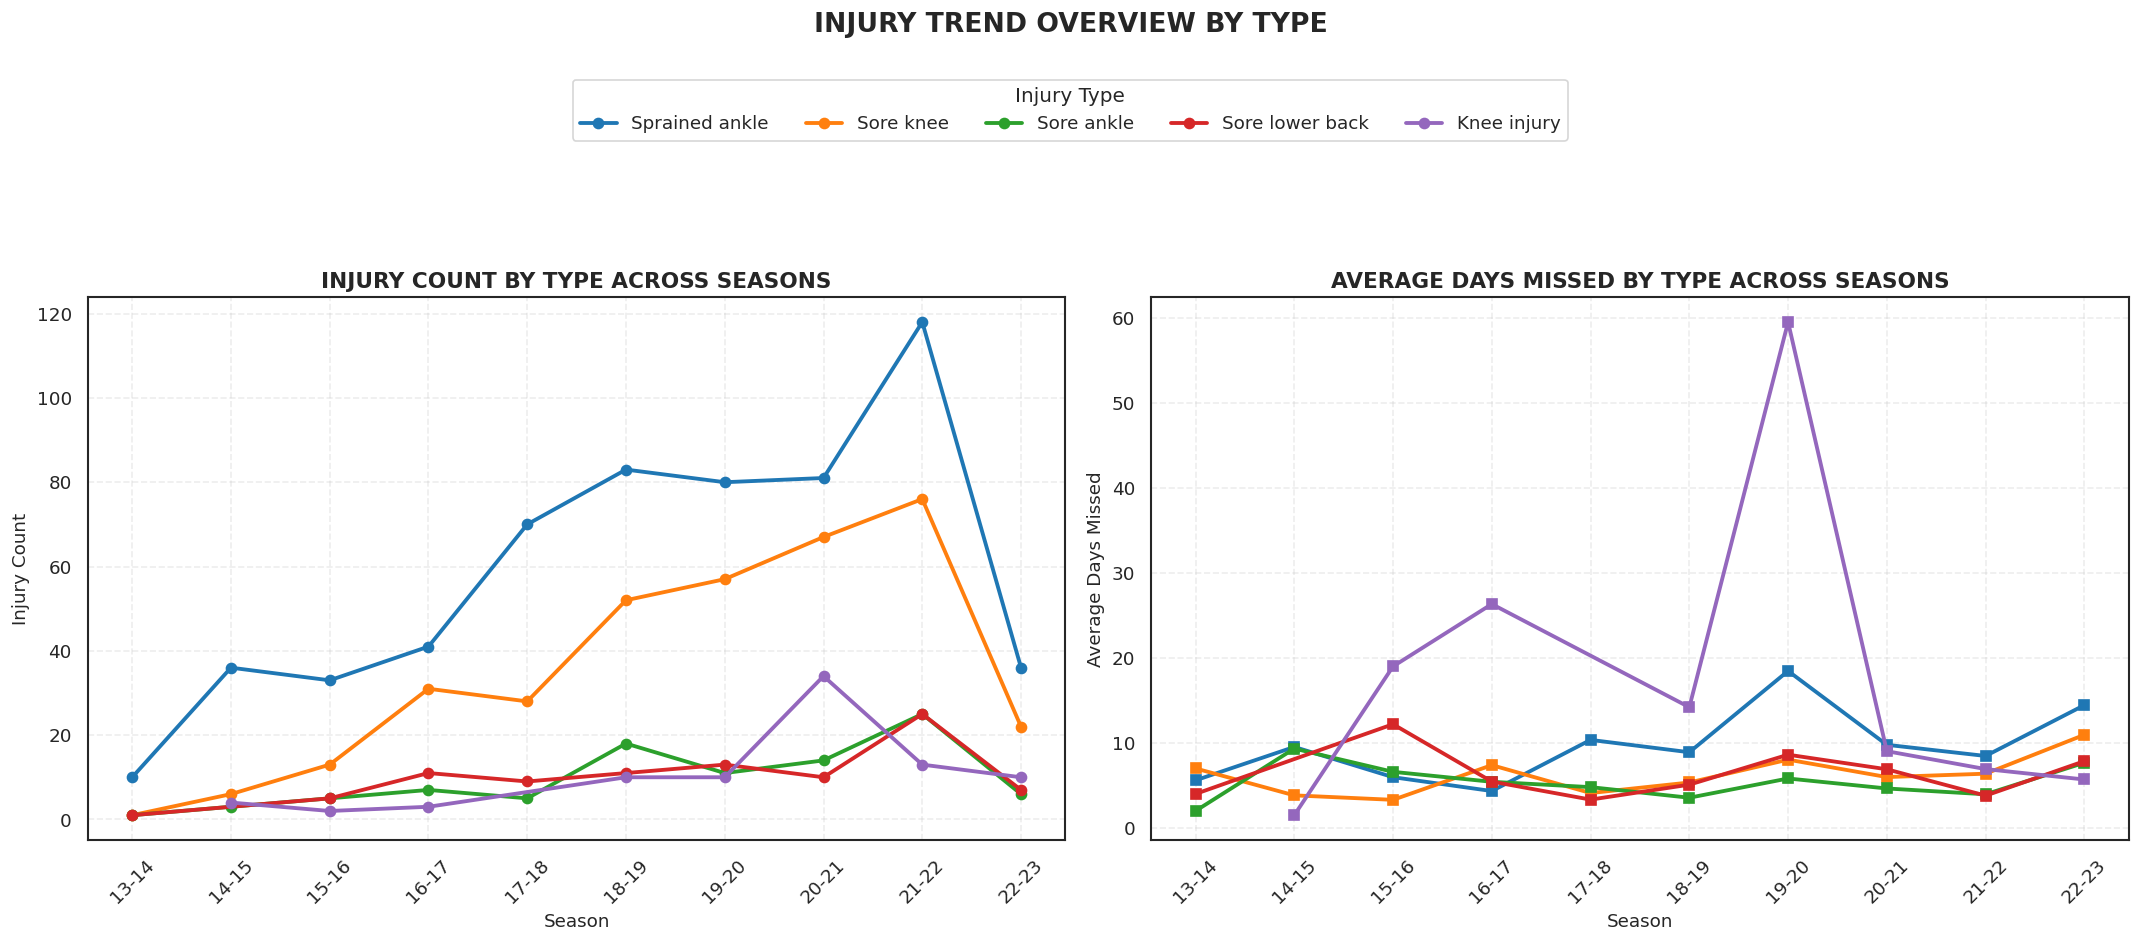

In [96]:
df_clean = df.dropna(subset=['INJURED_TYPE', 'SEASON', 'DAYS_MISSED'])

# 1) Lấy Top 5 loại chấn thương xuất hiện nhiều nhất
top_5_types = df_clean['INJURED_TYPE'].value_counts().nlargest(5).index.tolist()
df_top5 = df_clean[df_clean['INJURED_TYPE'].isin(top_5_types)].copy()

# 2) Tạo dữ liệu cho cả 2 chỉ số
seasonal_counts = (
    df_top5.groupby(['SEASON', 'INJURED_TYPE'])
    .size()
    .reset_index(name='INJURY_COUNT')
)

seasonal_avg = (
    df_top5.groupby(['SEASON', 'INJURED_TYPE'])['DAYS_MISSED']
    .mean()
    .reset_index(name='AVG_DAYS_MISSED')
)

merged = seasonal_counts.merge(
    seasonal_avg,
    on=['SEASON', 'INJURED_TYPE'],
    how='inner'
)
merged['INJURED_TYPE_LABEL'] = merged['INJURED_TYPE'].str.replace('_', ' ', regex=False).str.strip()
merged = merged.sort_values('SEASON')

# 3) 1 figure gồm 2 plot khác nhau đặt cạnh nhau
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharex=True)
ax1, ax2 = axes

palette = sns.color_palette('tab10', n_colors=len(top_5_types))
color_map = {t: palette[i] for i, t in enumerate(top_5_types)}

for inj_type in top_5_types:
    sub = merged[merged['INJURED_TYPE'] == inj_type]
    label = inj_type.replace('_', ' ').strip()
    color = color_map[inj_type]

    ax1.plot(
        sub['SEASON'],
        sub['INJURY_COUNT'],
        marker='o',
        linewidth=2.3,
        color=color,
        label=label
    )

    ax2.plot(
        sub['SEASON'],
        sub['AVG_DAYS_MISSED'],
        marker='s',
        linewidth=2.3,
        color=color,
        label=label
    )

ax1.set_title('INJURY COUNT BY TYPE ACROSS SEASONS', fontsize=13, fontweight='bold')
ax1.set_xlabel('Season', fontsize=11)
ax1.set_ylabel('Injury Count', fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.35)
ax1.tick_params(axis='x', rotation=45)

ax2.set_title('AVERAGE DAYS MISSED BY TYPE ACROSS SEASONS', fontsize=13, fontweight='bold')
ax2.set_xlabel('Season', fontsize=11)
ax2.set_ylabel('Average Days Missed', fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.35)
ax2.tick_params(axis='x', rotation=45)

# 1 legend duy nhất cho cả figure
handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, title='Injury Type', loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=5)

fig.suptitle('INJURY TREND OVERVIEW BY TYPE', fontsize=16, fontweight='bold', y=1.12)
fig.tight_layout()
fig.subplots_adjust(top=0.78)

plt.savefig('injury_trends_two_subplots_one_figure.png', dpi=300, bbox_inches='tight')
print("Đã lưu biểu đồ vào file 'injury_trends_two_subplots_one_figure.png'")

# Xuất bảng số liệu để tham khảo
pivot_count = merged.pivot(index='SEASON', columns='INJURED_TYPE_LABEL', values='INJURY_COUNT').fillna(0)
pivot_avg = merged.pivot(index='SEASON', columns='INJURED_TYPE_LABEL', values='AVG_DAYS_MISSED').fillna(0)
# print("\nBảng số ca chấn thương:")
# print(pivot_count)
# print("\nBảng số ngày nghỉ trung bình:")
# print(pivot_avg.round(2))
plt.show()

## 3) Tuổi tác ảnh hưởng như thế nào
Xem phân phối ngày nghỉ theo nhóm tuổi và xu hướng tổng quát giữa tuổi với `DAYS MISSED`.

,AGE_GROUP,total_players,injury_count,injury_probability
0,<23,975,220,22.564103
1,23-26,2101,392,18.657782
2,27-30,1462,355,24.281806
3,31-34,765,202,26.405229
4,35+,269,45,16.728625


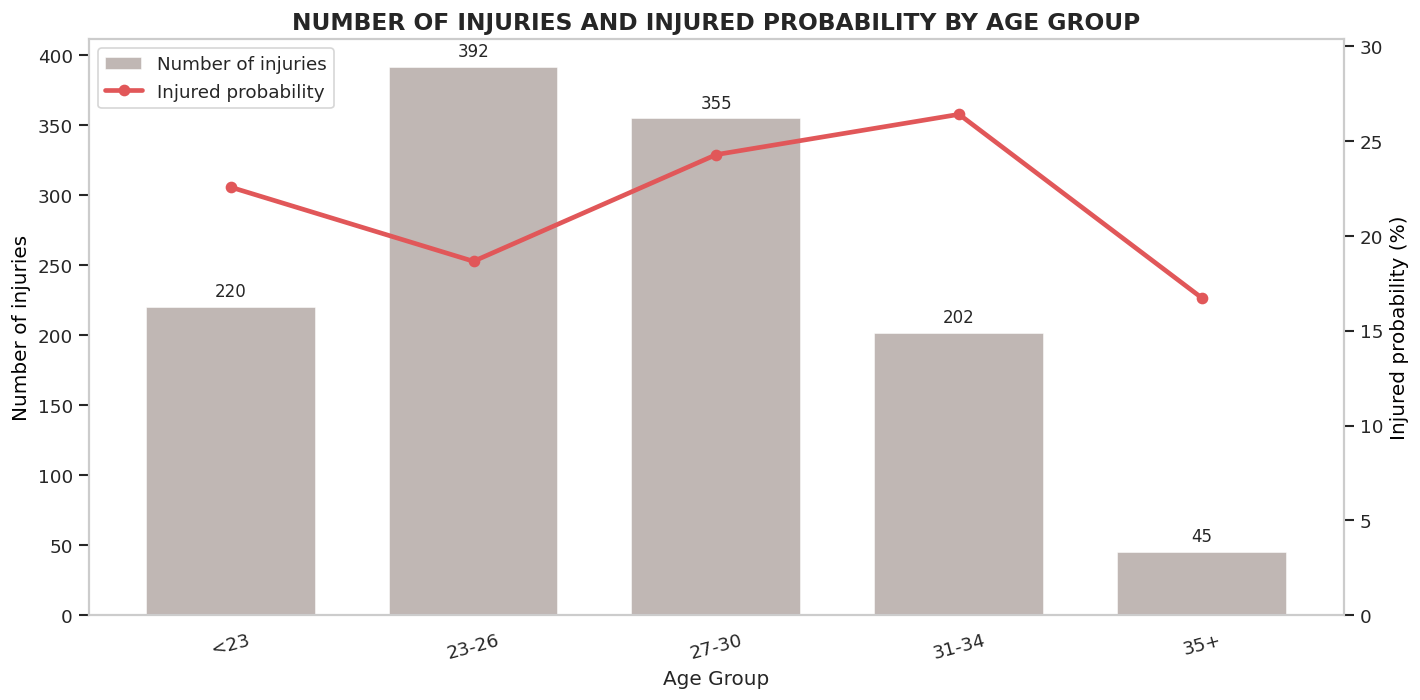

In [105]:
if "AGE" in df.columns and "injury_flag" in df.columns:
    age_tmp = df[["AGE", "injury_flag"]].dropna(subset=["AGE"]).copy()

    # 5 bins tuổi cố định
    age_bins = [-np.inf, 23, 27, 31, 35, np.inf]
    age_labels = ["<23", "23-26", "27-30", "31-34", "35+"]
    age_tmp["AGE_GROUP"] = pd.cut(
        age_tmp["AGE"],
        bins=age_bins,
        labels=age_labels,
        right=False
    )

    # Số ca chấn thương và xác suất chấn thương theo từng bin
    age_summary = (
        age_tmp.groupby("AGE_GROUP", observed=False)
        .agg(
            total_players=("injury_flag", "size"),
            injury_count=("injury_flag", "sum")
        )
        .reindex(age_labels)
        .reset_index()
    )
    age_summary["injury_probability"] = (
        age_summary["injury_count"] / age_summary["total_players"].replace(0, np.nan)
    ).fillna(0.0) * 100
    display(age_summary)

    x = np.arange(len(age_labels))

    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Bar màu xanh: số ca chấn thương (trục trái)
    bars = ax1.bar(
        x,
        age_summary["injury_count"],
        color="#BAB0AC",
        alpha=0.9,
        width=0.7,
        label="Number of injuries"
    )
    ax1.set_ylabel("Number of injuries", color="#000000", fontsize=12)
    ax1.set_xlabel("Age Group", fontsize=12)
    ax1.set_xticks(x)
    ax1.set_xticklabels(age_labels, rotation=15)
    
    # Tắt hoàn toàn grid của trục trái
    ax1.grid(False)

    # Line đỏ (overlay): injured probability (trục phải)
    ax2 = ax1.twinx()
    
    # Tắt hoàn toàn grid của trục phải (tránh trường hợp theme mặc định bật lên)
    ax2.grid(False)

    prob_line = ax2.plot(
        x,
        age_summary["injury_probability"],
        color="#E15759",
        marker="o",
        linewidth=2.8,
        label="Injured probability"
    )
    ax2.set_ylabel("Injured probability (%)", color="#020000", fontsize=12)
    ax2.set_ylim(0, max(0.35, age_summary["injury_probability"].max() * 1.15))

    # Nhãn số trên cột
    for b in bars:
        h = int(b.get_height())
        ax1.annotate(
            f"{h}",
            (b.get_x() + b.get_width() / 2, b.get_height()),
            ha="center",
            va="bottom",
            fontsize=10,
            xytext=(0, 4),
            textcoords="offset points"
        )

    # Legend chung
    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax1.legend(h1 + h2, l1 + l2, loc="upper left")

    plt.title("NUMBER OF INJURIES AND INJURED PROBABILITY BY AGE GROUP", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig('injury_analysis_by_age_group.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("Missing required columns for section 3.")

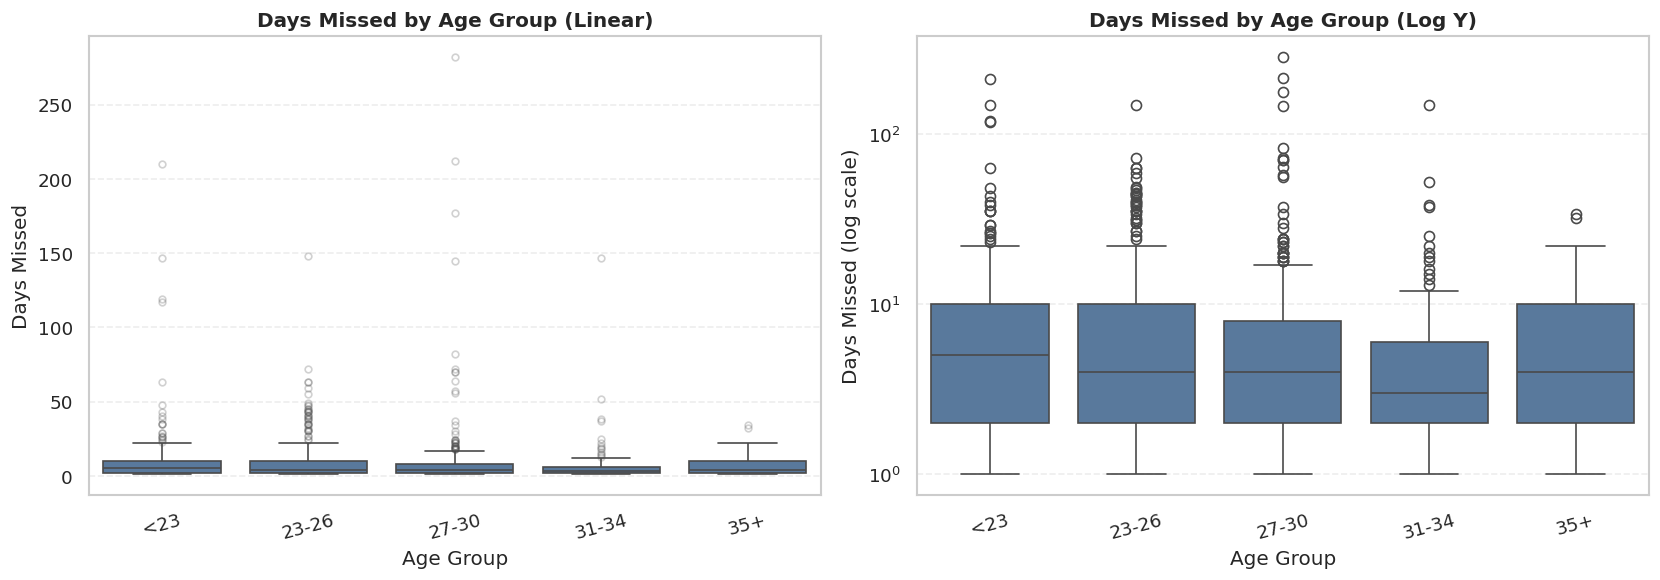

In [119]:
# Plot bổ sung: Box plot của days missed theo từng nhóm tuổi (linear vs log y)
if "AGE" in df.columns and days_col in df.columns:
    age_days_df = df[["AGE", days_col]].dropna(subset=["AGE", days_col]).copy()

    age_bins = [-np.inf, 23, 27, 31, 35, np.inf]
    age_labels = ["<23", "23-26", "27-30", "31-34", "35+"]
    age_days_df["AGE_GROUP"] = pd.cut(
        age_days_df["AGE"],
        bins=age_bins,
        labels=age_labels,
        right=False
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

    flierprops = dict(marker='o', markersize=4, alpha=0.25)
    # Subplot 1: trục y gốc
    sns.boxplot(
        data=age_days_df,
        x="AGE_GROUP",
        y=days_col,
        color="#4e79a7",
        order=age_labels,
        ax=axes[0],
        flierprops=dict(marker='o', markersize=4, alpha=0.25)
    )
    axes[0].set_title("Days Missed by Age Group (Linear)", fontsize=12, fontweight="bold")
    axes[0].set_xlabel("Age Group")
    axes[0].set_ylabel("Days Missed")
    axes[0].tick_params(axis="x", rotation=15)
    axes[0].grid(True, axis="y", linestyle="--", alpha=0.35)

    # Subplot 2: trục y log
    sns.boxplot(
        data=age_days_df,
        x="AGE_GROUP",
        y=days_col,
        color="#4e79a7",
        order=age_labels,
        ax=axes[1]
    )
    axes[1].set_yscale("log")
    axes[1].set_title("Days Missed by Age Group (Log Y)", fontsize=12, fontweight="bold")
    axes[1].set_xlabel("Age Group")
    axes[1].set_ylabel("Days Missed (log scale)")
    axes[1].tick_params(axis="x", rotation=15)
    axes[1].grid(True, axis="y", linestyle="--", alpha=0.35)

    plt.tight_layout()
    plt.show()
else:
    print("Missing required columns for boxplot-by-age.")

## 4) Lối chơi (pace/speed/drives/touches) ảnh hưởng thế nào
Dùng các biến phong cách chơi để xem tương quan với rủi ro và mức độ chấn thương.

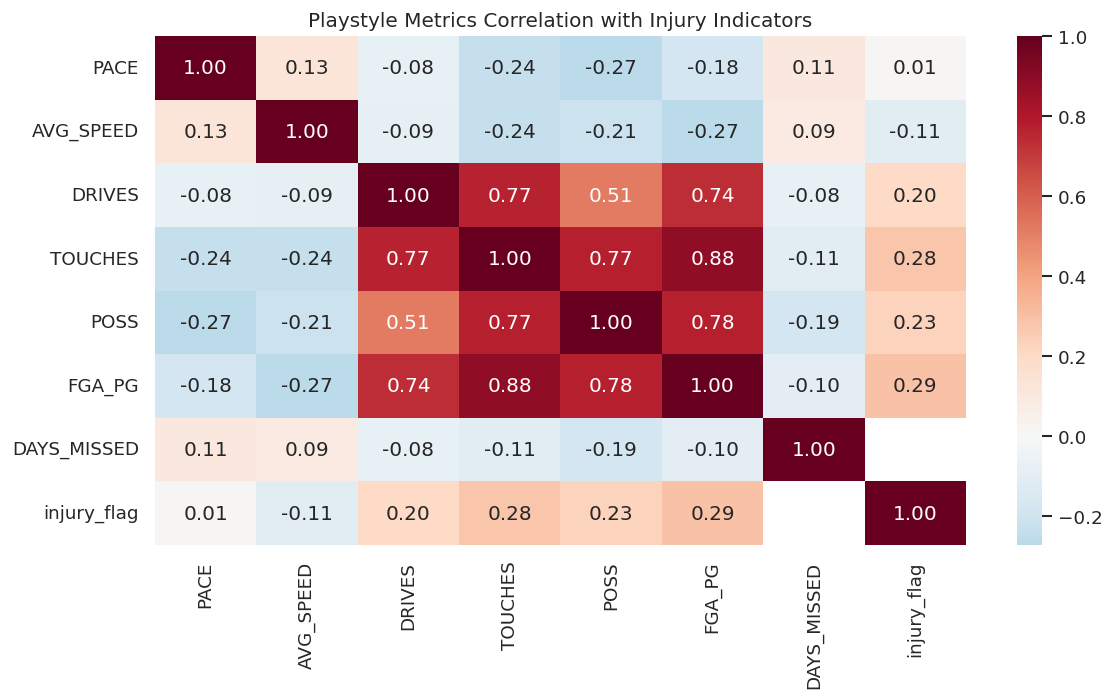

,abs_corr_with_days_missed
POSS,0.186464
TOUCHES,0.108570
PACE,0.105977
FGA_PG,0.102933
AVG_SPEED,0.086115
DRIVES,0.080042


In [99]:
style_cols = [c for c in ["PACE", "AVG_SPEED", "DRIVES", "TOUCHES", "POSS", "FGA_PG"] if c in df.columns]

if style_cols and days_col in df.columns:
    style_df = df[style_cols + [days_col, "injury_flag"]].copy()
    corr_cols = style_cols + [days_col, "injury_flag"]
    corr = style_df[corr_cols].corr(numeric_only=True)

    plt.figure(figsize=(10, 6))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0)
    plt.title("Playstyle Metrics Correlation with Injury Indicators")
    plt.tight_layout()
    plt.show()

    # Rank playstyle variables by |correlation| with days missed
    ranking = (
        corr[days_col]
        .drop(labels=[days_col], errors="ignore")
        .dropna()
        .abs()
        .sort_values(ascending=False)
        .rename("abs_corr_with_days_missed")
    )
    display(ranking.to_frame().head(10))
else:
    print("Missing required columns for section 4.")

## 5) Tỉ lệ chấn thương theo đội và ảnh hưởng tới kết quả đội
Dataset chưa có wins/losses trực tiếp, nên dùng proxy hiệu suất đội:
- `avg_GP`: số trận trung bình cầu thủ ra sân
- `avg_MIN`: số phút trung bình
Đồng thời so với mức gánh nặng chấn thương của đội.

,rows,injury_rate,total_days_missed,avg_days_missed,avg_GP,avg_MIN
TEAM,,,,,,
Suns,42,1.0,716.0,17.048,55.929,22.869
Thunder,43,1.0,622.0,14.465,55.512,24.960
Raptors,47,1.0,510.0,10.851,56.043,24.428
Pacers,55,1.0,510.0,9.273,54.182,24.527
Magic,39,1.0,494.0,12.667,56.308,26.005
Grizzlies,43,1.0,460.0,10.698,50.000,25.307
Cavaliers,50,1.0,425.0,8.500,54.360,23.344
Mavericks,46,1.0,415.0,9.022,54.239,23.413
Heat,43,1.0,412.0,9.581,60.209,27.479


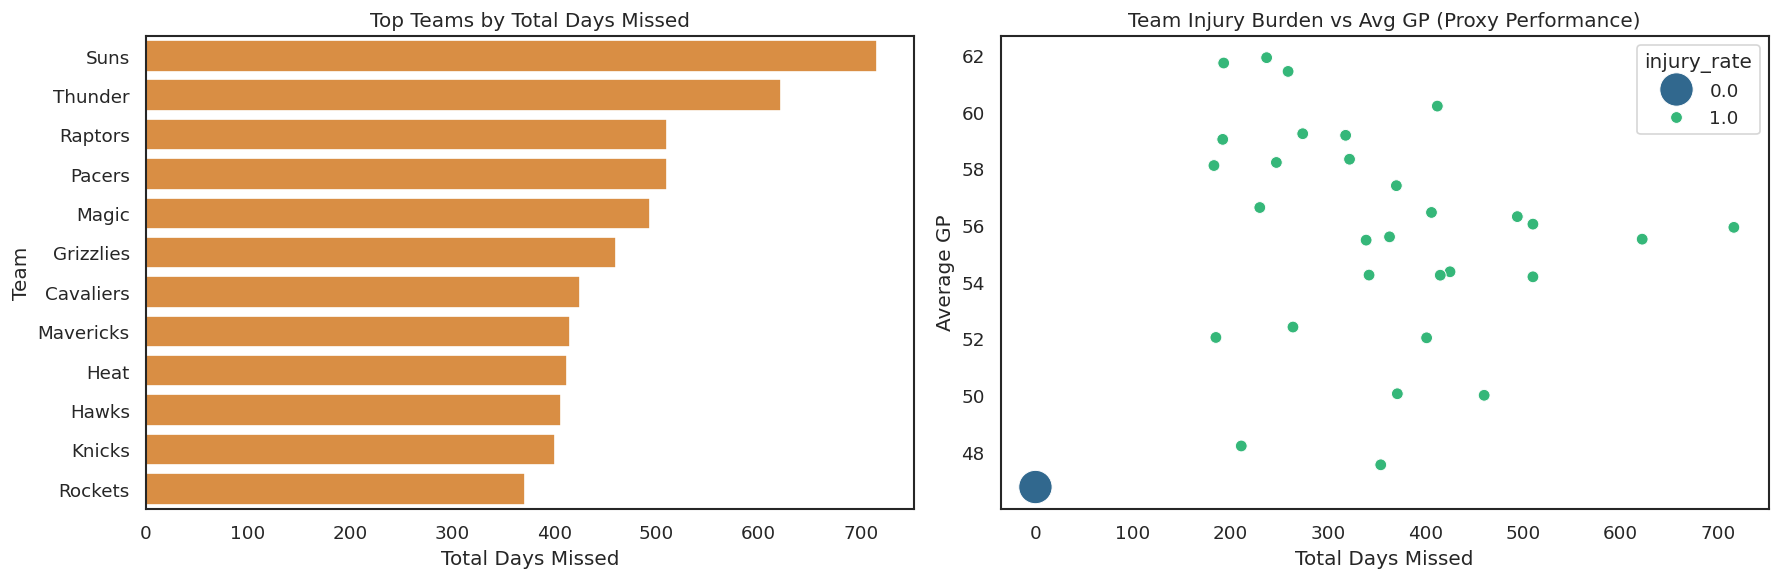

In [100]:
team_col = "TEAM"

if team_col in df.columns and days_col in df.columns:
    team_summary = (
        df.groupby(team_col, dropna=False)
        .agg(
            rows=(team_col, "size"),
            injury_rate=("injury_flag", "mean"),
            total_days_missed=(days_col, "sum"),
            avg_days_missed=(days_col, "mean"),
            avg_GP=("GP", "mean") if "GP" in df.columns else (days_col, "mean"),
            avg_MIN=("MIN", "mean") if "MIN" in df.columns else (days_col, "mean")
        )
        .sort_values("total_days_missed", ascending=False)
    )
    display(team_summary.head(15).round(3))

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    top_team = team_summary.head(12).reset_index()
    sns.barplot(data=top_team, x="total_days_missed", y=team_col, ax=axes[0], color="#f28e2b")
    axes[0].set_title("Top Teams by Total Days Missed")
    axes[0].set_xlabel("Total Days Missed")
    axes[0].set_ylabel("Team")

    sns.scatterplot(data=team_summary.reset_index(), x="total_days_missed", y="avg_GP", size="injury_rate", hue="injury_rate", ax=axes[1], palette="viridis", sizes=(50, 400))
    axes[1].set_title("Team Injury Burden vs Avg GP (Proxy Performance)")
    axes[1].set_xlabel("Total Days Missed")
    axes[1].set_ylabel("Average GP")

    plt.tight_layout()
    plt.show()
else:
    print("Missing required columns for section 5.")

## 6) Heatmap correlation giữa các chỉ số
Tập trung vào biến số chính và các chỉ báo chấn thương (`injury_flag`, `DAYS MISSED`).

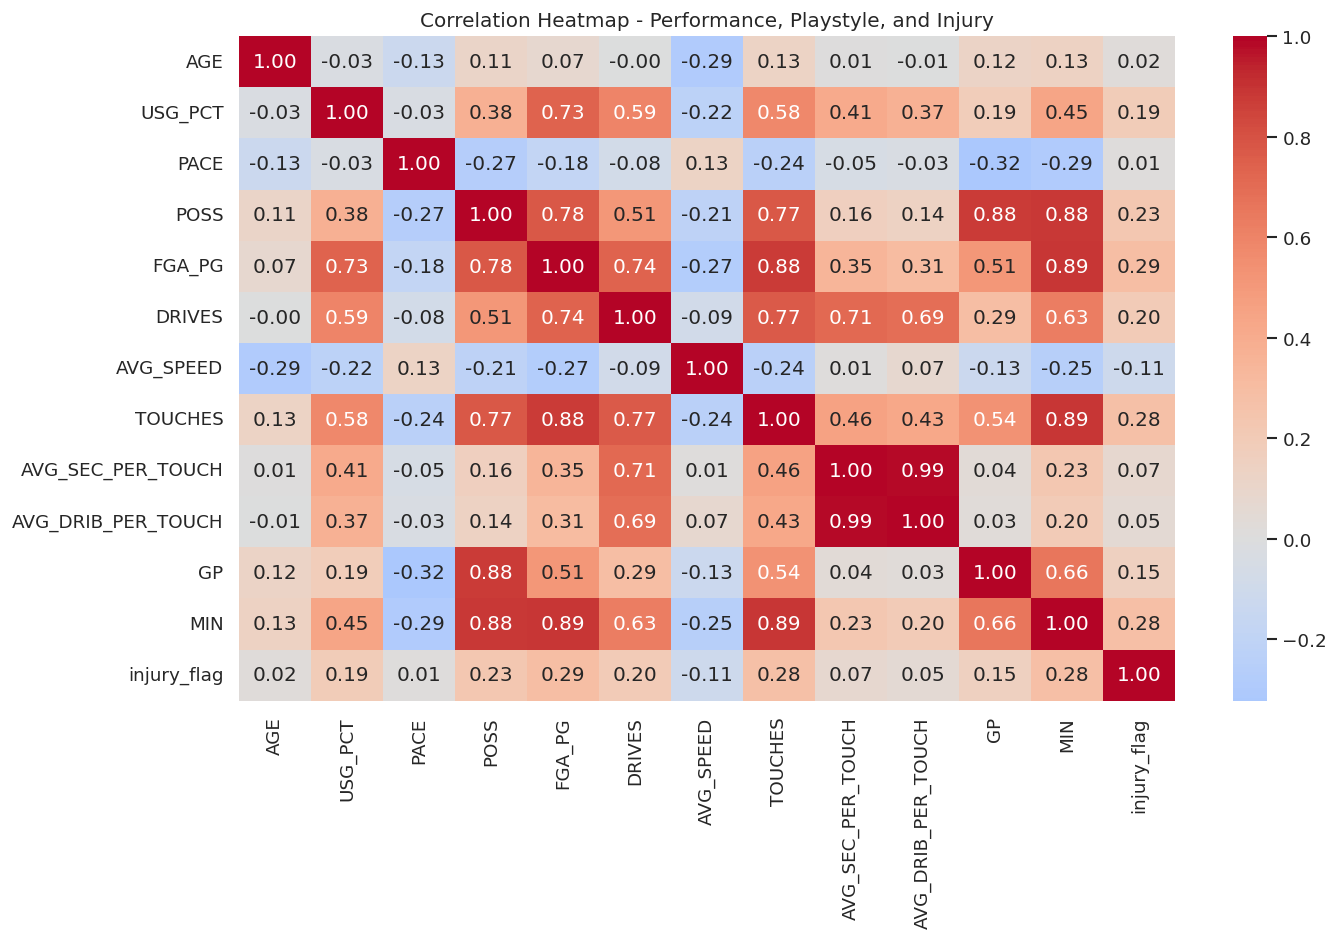

In [101]:
candidate_cols = [
    "AGE", "USG_PCT", "PACE", "POSS", "FGA_PG", "DRIVES", "AVG_SPEED",
    "TOUCHES", "AVG_SEC_PER_TOUCH", "AVG_DRIB_PER_TOUCH", "GP", "MIN", "DAYS MISSED"
]
num_focus = [c for c in candidate_cols if c in df.columns]

if len(num_focus) >= 3:
    corr_df = df[num_focus + ["injury_flag"]].copy()
    corr_mx = corr_df.corr(numeric_only=True)

    plt.figure(figsize=(12, 8))
    sns.heatmap(corr_mx, cmap="coolwarm", center=0, annot=True, fmt=".2f")
    plt.title("Correlation Heatmap - Performance, Playstyle, and Injury")
    plt.tight_layout()
    plt.show()
else:
    print("Not enough numeric columns for section 6.")

## 7) Cầu thủ thường chấn thương vào giai đoạn nào của mùa
Phân loại tháng bị chấn thương thành 3 phase:
- Early: 10-12
- Mid: 1-3
- Late: 4-6

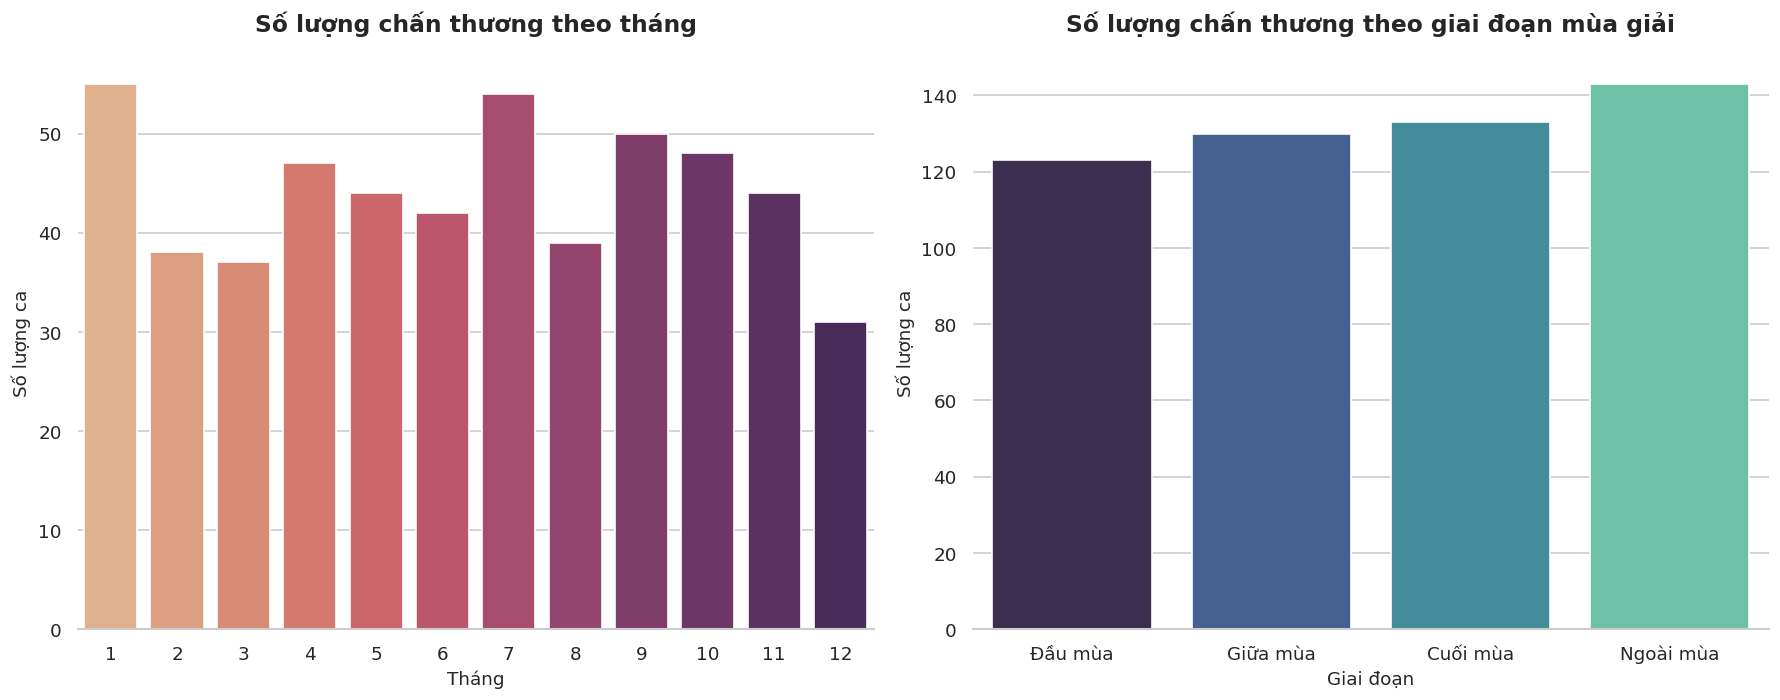

In [102]:
import matplotlib.pyplot as plt
import seaborn as sns

# Cấu hình phong cách hiển thị chuyên nghiệp
sns.set_theme(style="whitegrid", font="sans-serif")
plt.rcParams['figure.dpi'] = 120  # Tăng độ sắc nét cho màn hình hiện đại

if injury_date_col in df.columns:
    # 1. Tiền xử lý dữ liệu thời gian
    season_df = df[df[injury_date_col].notna()].copy()
    season_df["injury_month"] = season_df[injury_date_col].dt.month

    # 2. Ánh xạ giai đoạn mùa giải sang Tiếng Việt
    # Logic: Phân nhóm các tháng rời rạc vào các giai đoạn có tính thứ tự
    phase_map = {
        10: "Đầu mùa", 11: "Đầu mùa", 12: "Đầu mùa",
        1: "Giữa mùa", 2: "Giữa mùa", 3: "Giữa mùa",
        4: "Cuối mùa", 5: "Cuối mùa", 6: "Cuối mùa",
        7: "Ngoài mùa", 8: "Ngoài mùa", 9: "Ngoài mùa"
    }
    season_df["season_phase"] = season_df["injury_month"].map(phase_map).fillna("Không xác định")

    # Tính toán thống kê
    month_counts = season_df["injury_month"].value_counts().sort_index()
    phase_counts = season_df["season_phase"].value_counts()

    # 3. Khởi tạo biểu đồ
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Biểu đồ trái: Theo tháng (Sử dụng bảng màu 'flare' để tạo chiều sâu)
    sns.barplot(
        x=month_counts.index,
        y=month_counts.values,
        ax=axes[0],
        palette="flare",
        hue=month_counts.index,
        legend=False
    )
    axes[0].set_title("Số lượng chấn thương theo tháng", fontsize=14, weight='bold', pad=15)
    axes[0].set_xlabel("Tháng", fontsize=11)
    axes[0].set_ylabel("Số lượng ca", fontsize=11)

    # Biểu đồ phải: Theo giai đoạn (Sử dụng bảng màu 'viridis' chuyên nghiệp)
    order = ["Đầu mùa", "Giữa mùa", "Cuối mùa", "Ngoài mùa"]
    phase_plot = phase_counts.reindex(order).fillna(0)

    sns.barplot(
        x=phase_plot.index,
        y=phase_plot.values,
        ax=axes[1],
        palette="mako",
        hue=phase_plot.index,
        legend=False
    )
    axes[1].set_title("Số lượng chấn thương theo giai đoạn mùa giải", fontsize=14, weight='bold', pad=15)
    axes[1].set_xlabel("Giai đoạn", fontsize=11)
    axes[1].set_ylabel("Số lượng ca", fontsize=11)

    # Tinh chỉnh cuối cùng
    sns.despine(left=True)
    plt.tight_layout()
    plt.show()
else:
    print(f"Lỗi: Không tìm thấy cột ngày chấn thương '{injury_date_col}' trong dữ liệu.")

## 8) Ảnh hưởng tài chính tới đội bóng
Không có salary trong dataset, nên xây dựng **financial impact proxy**:
- `cost_proxy = DAYS MISSED * MIN * (USG_PCT + 1e-3)`
Ý tưởng: cầu thủ nghỉ lâu, chơi nhiều phút, usage cao thường để lại chi phí cơ hội lớn hơn.

In [103]:
need_cols = ["DAYS MISSED", "MIN", "USG_PCT", "TEAM"]
if all(c in df.columns for c in need_cols):
    fin_df = df.copy()
    fin_df["cost_proxy"] = fin_df["DAYS MISSED"].fillna(0) * fin_df["MIN"].fillna(0) * (fin_df["USG_PCT"].fillna(0) + 1e-3)

    team_cost = (
        fin_df.groupby("TEAM", dropna=False)
        .agg(
            total_cost_proxy=("cost_proxy", "sum"),
            avg_cost_proxy=("cost_proxy", "mean"),
            total_days_missed=("DAYS MISSED", "sum")
        )
        .sort_values("total_cost_proxy", ascending=False)
    )
    display(team_cost.head(15).round(2))

    plt.figure(figsize=(10, 6))
    top_cost = team_cost.head(12).reset_index()
    sns.barplot(data=top_cost, x="total_cost_proxy", y="TEAM", color="#edc948")
    plt.title("Top Teams by Financial Impact Proxy")
    plt.xlabel("Total Cost Proxy")
    plt.ylabel("Team")
    plt.tight_layout()
    plt.show()
else:
    print("Missing required columns for section 8.")

Missing required columns for section 8.


## 9) Sự suy giảm hiệu suất sau khi bình phục
Dataset không có split trước/sau theo game log, nên dùng proxy:
- Nhóm cầu thủ theo mức `DAYS MISSED`
- So sánh `GP` và `MIN` trung bình của các nhóm để thấy tín hiệu giảm tải sau chấn thương nặng.

In [104]:
if all(c in df.columns for c in ["DAYS MISSED", "GP", "MIN"]):
    rec_df = df[df["injury_flag"]].copy()
    rec_df = rec_df.dropna(subset=["DAYS MISSED"])

    rec_df["severity_group"] = pd.cut(
        rec_df["DAYS MISSED"],
        bins=[-1, 7, 21, 60, np.inf],
        labels=["Minor (<=7)", "Moderate (8-21)", "Major (22-60)", "Severe (60+)"]
    )

    rec_summary = rec_df.groupby("severity_group", observed=False).agg(
        rows=("severity_group", "size"),
        avg_GP=("GP", "mean"),
        avg_MIN=("MIN", "mean"),
        avg_USG=("USG_PCT", "mean") if "USG_PCT" in rec_df.columns else ("GP", "mean")
    )
    display(rec_summary.round(2))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    rec_plot = rec_summary.reset_index()

    sns.barplot(data=rec_plot, x="severity_group", y="avg_GP", ax=axes[0], color="#b07aa1")
    axes[0].set_title("Avg GP by Injury Severity Group")
    axes[0].set_xlabel("Injury Severity Group")
    axes[0].set_ylabel("Average GP")
    axes[0].tick_params(axis="x", rotation=20)

    sns.barplot(data=rec_plot, x="severity_group", y="avg_MIN", ax=axes[1], color="#ff9da7")
    axes[1].set_title("Avg MIN by Injury Severity Group")
    axes[1].set_xlabel("Injury Severity Group")
    axes[1].set_ylabel("Average MIN")
    axes[1].tick_params(axis="x", rotation=20)

    plt.tight_layout()
    plt.show()
else:
    print("Missing required columns for section 9.")

Missing required columns for section 9.
